### Ejemplo de los Mensajes para el juego de la *Cadena* de Myerson

Se tata de la situación de comnicación de Myerson representado por la cadena abajo dibujada. La matriz de adyacencia de este grafo es la siguiente:

$$ \begin{bmatrix}
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0
\end{bmatrix} $$

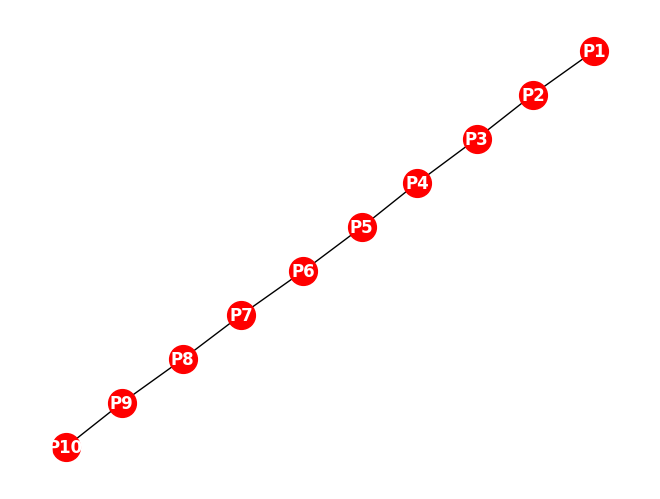

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import shap

adjacency = pd.DataFrame([
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
])
index = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7",
    "P8",
    "P9",
    "P10",
]
adjacency.columns = index
adjacency["index"] = index
adjacency = adjacency.set_index("index", verify_integrity=True)

g = nx.from_pandas_adjacency(adjacency)
pos = nx.kamada_kawai_layout(g)
nx.draw(
    g, pos, with_labels=True,
    node_color="red", font_color="white",
    font_weight="bold", node_size=400
)

In [ ]:
import os
import sys
import math
import pandas as pd


file_root_shapley = os.path.join(
    "..", "..", "data", "exact", "shapley_value_of_myerson_coalitions_chain.csv"
)
file_root_grabisch = os.path.join(
    "..", "..", "data", "exact", "grabisch_of_myerson_coalitions_chain.csv"
)

index = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7",
    "P8",
    "P9",
    "P10",
]
shapley_only = pd.read_csv(
    file_root_shapley,
    sep=";",
    header=None,
    names=["value"]
)
shapley_only["player"] = index
psi_1 = shapley_only.set_index("player", verify_integrity=True)

r_1 = pd.read_csv(
    file_root_grabisch,
    sep=";",
    header=0
)
r_1.columns = index
r_1["player"] = index
r_1 = r_1.set_index("player", verify_integrity=True)

### Truncated characteristic values

In [4]:
from cgt_perezsechi.manipulation.norm import normalize_psi, normalize_r


n = 4
psi_1_truncated = psi_1.copy()
psi_1_truncated["value"] = psi_1_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_1_truncated = r_1.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

psi_2 = normalize_psi(psi_1)
psi_2_truncated = psi_2.copy()
psi_2_truncated["value"] = psi_2_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_2 = normalize_r(r_1)
r_2_truncated = r_2.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  max_edge_width = r.applymap(lambda x: abs(x)).max().max()
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(lambda x: x / max_edge_width)


#### Cost Allocation Results

The Shapley values for this game are calculated in the file ./data/exact/shapley_value_of_myerson_coalitions_chain.csv. In the table below we represent these values:

In [5]:
psi_1_truncated

,value
player,
P1,1.9289
P2,3.7579
P3,4.9757
P4,5.7353
P5,6.1019
P6,6.1019
P7,5.7353
P8,4.9757
P9,3.7579


In [6]:
psi_2_truncated

,value
player,
P1,0.3161
P2,0.6158
P3,0.8154
P4,0.9399
P5,1.0000
P6,1.0000
P7,0.9399
P8,0.8154
P9,0.6158


The Grabisch values of all the pairs in the game can be found in the file ./data/exact/grabisch_of_myerson_coalitions_chain.csv. In the following table, we represent these values.

In [7]:
r_1_truncated

,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10
player,,,,,,,,,,
P1,0.0000,2.8289,1.8289,1.3289,0.9956,0.7456,0.5456,0.3789,0.2361,0.1111
P2,2.8289,0.0000,4.5468,3.0468,2.2134,1.6301,1.1801,0.8134,0.5039,0.2361
P3,1.8289,4.5468,0.0000,5.6396,3.8063,2.7230,1.9396,1.3230,0.8134,0.3789
P4,1.3289,3.0468,5.6396,0.0000,6.2563,4.1730,2.8896,1.9396,1.1801,0.5456
P5,0.9956,2.2134,3.8063,6.2563,0.0000,6.4563,4.1730,2.7230,1.6301,0.7456
P6,0.7456,1.6301,2.7230,4.1730,6.4563,0.0000,6.2563,3.8063,2.2134,0.9956
P7,0.5456,1.1801,1.9396,2.8896,4.1730,6.2563,0.0000,5.6396,3.0468,1.3289
P8,0.3789,0.8134,1.3230,1.9396,2.7230,3.8063,5.6396,0.0000,4.5468,1.8289
P9,0.2361,0.5039,0.8134,1.1801,1.6301,2.2134,3.0468,4.5468,0.0000,2.8289


In [8]:
r_2_truncated

,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10
player,,,,,,,,,,
P1,0.0000,0.4381,0.2832,0.2058,0.1542,0.1154,0.0845,0.0586,0.0365,0.0172
P2,0.4381,0.0000,0.7042,0.4719,0.3428,0.2524,0.1827,0.1259,0.0780,0.0365
P3,0.2832,0.7042,0.0000,0.8735,0.5895,0.4217,0.3004,0.2049,0.1259,0.0586
P4,0.2058,0.4719,0.8735,0.0000,0.9690,0.6463,0.4475,0.3004,0.1827,0.0845
P5,0.1542,0.3428,0.5895,0.9690,0.0000,1.0000,0.6463,0.4217,0.2524,0.1154
P6,0.1154,0.2524,0.4217,0.6463,1.0000,0.0000,0.9690,0.5895,0.3428,0.1542
P7,0.0845,0.1827,0.3004,0.4475,0.6463,0.9690,0.0000,0.8735,0.4719,0.2058
P8,0.0586,0.1259,0.2049,0.3004,0.4217,0.5895,0.8735,0.0000,0.7042,0.2832
P9,0.0365,0.0780,0.1259,0.1827,0.2524,0.3428,0.4719,0.7042,0.0000,0.4381


In [9]:
shap_cmap = shap.plots.colors.red_blue
positive_color = shap_cmap(1.0)[:3]
negative_color = shap_cmap(0.0)[:3] 

####  $\Psi_{\alpha^{+} = 0, \alpha^{-} = 0}^{2}; R_{\beta^{+} = 0, \beta^{-} = 0}^{2}$

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/visualization/graph.py:91: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(filter_edge)
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/visualization/graph.py:92: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adjacency = r.copy().applymap(lambda x: 1 if x != 0 else 0)


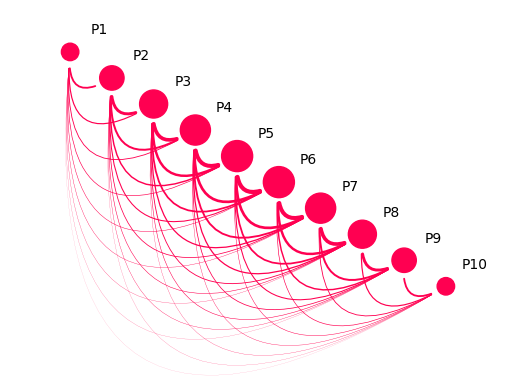

In [ ]:
import os
import sys
import numpy as np

from cgt_perezsechi.visualization.graph import draw

draw(
    psi=psi_2,
    r=r_2.where(np.triu(np.ones(r_2.shape)).astype(bool)).fillna(0),
    positive_alpha=0,
    negative_alpha=0,
    positive_beta=0,
    negative_beta=0,
    symmetric=True,
    arched=True,
    arch_radius=1,
    node_size_upper_limit=500,
    label_pos={
        'P1': np.array([0.7, 9.7]),
        'P2': np.array([1.7, 8.7]),
        'P3': np.array([2.7, 7.7]),
        'P4': np.array([3.7, 6.7]),
        'P5': np.array([4.7, 5.7]),
        'P6': np.array([5.7, 4.7]),
        'P7': np.array([6.7, 3.7]),
        'P8': np.array([7.7, 2.7]),
        'P9': np.array([8.7, 1.7]),
        'P10': np.array([9.7, 0.7]),
    },
    label_color='black',
    label_weight='normal',
    node_pos={
        'P1': np.array([0, 9]),
        'P2': np.array([1, 8]),
        'P3': np.array([2, 7]),
        'P4': np.array([3, 6]),
        'P5': np.array([4, 5]),
        'P6': np.array([5, 4]),
        'P7': np.array([6, 3]),
        'P8': np.array([7, 2]),
        'P9': np.array([8, 1]),
        'P10': np.array([9, 0]),
    },
    positive_color=positive_color,
    negative_color=negative_color,
    plot_margin=0.1,
)

####  $\Psi_{\alpha^{+} = 0, \alpha^{-} = 0}^{2}; R_{\beta^{+} = 0.4, \beta^{-} = 0}^{2}$

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/visualization/graph.py:91: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(filter_edge)
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/visualization/graph.py:92: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  adjacency = r.copy().applymap(lambda x: 1 if x != 0 else 0)


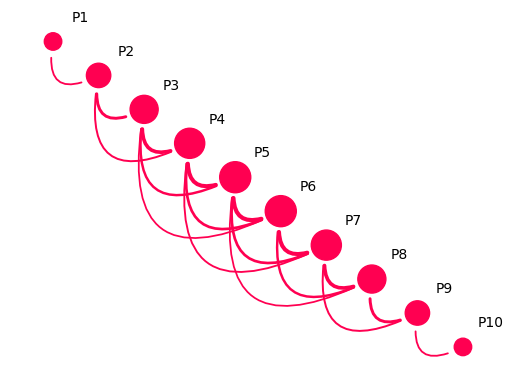

In [ ]:
import os
import sys
import numpy as np

from cgt_perezsechi.visualization.graph import draw

draw(
    psi=psi_2,
    r=r_2.where(np.triu(np.ones(r_2.shape)).astype(bool)).fillna(0),
    positive_alpha=0,
    negative_alpha=0,
    positive_beta=0.4,
    negative_beta=0,
    symmetric=True,
    arched=True,
    arch_radius=1,
    node_size_upper_limit=500,
    label_pos={
        'P1': np.array([0.6, 9.6]),
        'P2': np.array([1.6, 8.6]),
        'P3': np.array([2.6, 7.6]),
        'P4': np.array([3.6, 6.6]),
        'P5': np.array([4.6, 5.6]),
        'P6': np.array([5.6, 4.6]),
        'P7': np.array([6.6, 3.6]),
        'P8': np.array([7.6, 2.6]),
        'P9': np.array([8.6, 1.6]),
        'P10': np.array([9.6, 0.6]),
    },
    label_color='black',
    label_weight='normal',
    node_pos={
        'P1': np.array([0, 9]),
        'P2': np.array([1, 8]),
        'P3': np.array([2, 7]),
        'P4': np.array([3, 6]),
        'P5': np.array([4, 5]),
        'P6': np.array([5, 4]),
        'P7': np.array([6, 3]),
        'P8': np.array([7, 2]),
        'P9': np.array([8, 1]),
        'P10': np.array([9, 0]),
    },
    positive_color=positive_color,
    negative_color=negative_color,
)